W ramach ćwiczenia:
- Wykonać co najmniej 4 wybrane modele regresyjne i cztery klasyfikacyjne (mogą być te same)

- Wskazać najistotniejsze zmienne jednocześnie dla kilku (różnych) modeli

- Wskazać (jeśli są) zmienne istotne tylko dla jednego z modeli

- Dla najważniejszych dwóch zmiennych dla każdego z modeli wykonać boundary plots, wskazać obszary zasięgu zmiennych dla których wyjaśnienie jest wątpliwe

- Wybrać po jednym modelu regresyjnym i klasyfikacyjnym o wysokiej wydajności zarówno dla zmiennej kategoryzowanej jak i numerycznej na zbiorze testowym

- Wykonać ALE plots dla wszystkich zmiennych, wskazać zakresy wartości zmiennych decydujące o wyniku predykcji, wyjaśnić potencjalne przyczyny niskiej/wysokiej ważności w wybranych obszarach

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, f1_score, accuracy_score, precision_recall_fscore_support

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance, DecisionBoundaryDisplay

from alibi.explainers import ALE, plot_ale

In [ ]:
data = pd.read_csv("data/zal_piezometr.csv")
data.head()

In [9]:
# --- 0.1 Kontrola typów i klucza czasowego ---
df = data.copy()

# konwersja date -> datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Dtypes:\n", df.dtypes)
print("\nZakres dat:", df["date"].min(), "->", df["date"].max())
print("Liczba wierszy:", len(df))

# sprawdzenie błędnej konwersji dat
bad_dates = df["date"].isna().sum()
print("\nBrakujące/niepoprawne daty:", bad_dates)

# sortowanie po dacie (ważne przed splittem czasowym)
df = df.sort_values("date").reset_index(drop=True)

# duplikaty dat
dup_dates = df["date"].duplicated().sum()
print("Duplikaty dat:", dup_dates)
if dup_dates:
    print(df.loc[df["date"].duplicated(keep=False), ["date"]].head(10))

# --- 0.2 Braki danych ---
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts = na_counts[na_counts > 0]
print("\nBraki danych (kolumny z NA):")
print(na_counts if len(na_counts) else "Brak braków danych")

# jeśli są braki w targetach, to trzeba je usunąć (nie imputować)
targets = ["waterlv", "raise"]
missing_targets = df[targets].isna().any(axis=1).sum()
print("\nWiersze z brakami w waterlv/raise:", missing_targets)
if missing_targets:
    df = df.dropna(subset=targets).reset_index(drop=True)
    print("Po usunięciu braków w targetach, liczba wierszy:", len(df))

# --- 0.3 Szybki przegląd rozkładów/outlierów (numeryczne) ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nLiczba kolumn numerycznych:", len(num_cols))

desc = df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc["iqr"] = desc["75%"] - desc["25%"]
desc["out_low_iqr"] = desc["25%"] - 1.5 * desc["iqr"]
desc["out_high_iqr"] = desc["75%"] + 1.5 * desc["iqr"]
print("\nDescribe z percentylami + progi IQR (podgląd):")
display(desc)

# (opcjonalnie) policz liczbę obserwacji poza progami IQR dla każdej kolumny
outlier_counts = {}
for c in num_cols:
    low, high = desc.loc[c, "out_low_iqr"], desc.loc[c, "out_high_iqr"]
    outlier_counts[c] = int(((df[c] < low) | (df[c] > high)).sum())
outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)
print("\nLiczba potencjalnych outlierów wg reguły 1.5*IQR (top 10):")
display(outlier_counts.head(10))

# --- 0.4 Definicja X / y dla regresji i klasyfikacji ---
y_reg = df["waterlv"].astype(float)

# raise bywa bool, 0/1 albo "True"/"False" - ujednolicamy do 0/1
if df["raise"].dtype == bool:
    y_clf = df["raise"].astype(int)
else:
    y_clf = df["raise"].map({True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0}).astype(int)

feature_cols = [c for c in df.columns if c not in ["date", "waterlv", "raise"]]
X = df[feature_cols].copy()

print("\nShape X:", X.shape)
print("Reg target shape:", y_reg.shape, " |  Clf target shape:", y_clf.shape)
print("Klasy raise (liczebności):")
display(y_clf.value_counts())

# --- 0.5 Podział train/test w czasie (80/20) ---
# UWAGA: to NIE jest walidacja krocząca; to prosty hold-out z zachowaniem chronologii
split_frac = 0.8
split_idx = int(len(df) * split_frac)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]
y_clf_train, y_clf_test = y_clf.iloc[:split_idx], y_clf.iloc[split_idx:]

date_train, date_test = df["date"].iloc[:split_idx], df["date"].iloc[split_idx:]

print("\nTRAIN:", date_train.min(), "->", date_train.max(), "| n =", len(X_train))
print("TEST :", date_test.min(), "->", date_test.max(), "| n =", len(X_test))

# szybki sanity check: czy rozkład klas nie "ucieka" drastycznie w czasie?
print("\nRaise ratio train:", y_clf_train.mean().round(3), " | test:", y_clf_test.mean().round(3))

Dtypes:
 date         datetime64[ns]
watertemp           float64
sealv               float64
precip              float64
temp                float64
vwind               float64
dwind               float64
sin                 float64
cos                 float64
precip1             float64
precip2             float64
precip3             float64
precip4             float64
precip5             float64
precipsum           float64
meantemp            float64
raise                  bool
waterlv             float64
dtype: object

Zakres dat: 2008-09-28 00:00:00 -> 2014-10-31 00:00:00
Liczba wierszy: 2129

Brakujące/niepoprawne daty: 0
Duplikaty dat: 0

Braki danych (kolumny z NA):
Brak braków danych

Wiersze z brakami w waterlv/raise: 0

Liczba kolumn numerycznych: 16

Describe z percentylami + progi IQR (podgląd):


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,out_low_iqr,out_high_iqr
watertemp,2129.0,9.550714,2.011780,6.32,6.450000,6.820000,7.690000,9.33000,11.570000,12.550000,12.750000,12.800000,3.880000,1.870000,17.390000
sealv,2129.0,506.334171,19.060688,449.27,464.170000,476.000000,494.330000,506.00000,516.600000,539.452000,558.720000,611.440000,22.270000,460.925000,550.005000
precip,2129.0,1.905838,4.318492,0.00,0.000000,0.000000,0.000000,0.09000,1.700000,10.060000,21.436000,47.000000,1.700000,-2.550000,4.250000
temp,2129.0,7.919333,7.436094,-16.58,-9.444400,-4.130000,2.630000,7.59000,13.980000,19.330000,22.900800,27.810000,11.350000,-14.395000,31.005000
vwind,2129.0,4.606801,2.243889,0.38,1.250000,1.880000,3.000000,4.13000,5.750000,8.880000,11.250000,16.500000,2.750000,-1.125000,9.875000
dwind,2129.0,180.649624,70.911251,13.75,37.500000,56.250000,125.000000,192.50000,238.750000,277.500000,304.650000,350.000000,113.750000,-45.625000,409.375000
sin,2129.0,-0.077259,0.746914,-1.00,-0.999762,-0.995611,-0.831470,-0.21644,0.728371,0.984808,0.999425,1.000000,1.559841,-3.171230,3.068132
cos,2129.0,-0.412117,0.516428,-1.00,-0.999762,-0.994056,-0.876727,-0.53730,-0.065403,0.600419,0.843391,0.984808,0.811324,-2.093712,1.151582
precip1,2129.0,1.909549,4.320333,0.00,0.000000,0.000000,0.000000,0.09000,1.700000,10.060000,21.436000,47.000000,1.700000,-2.550000,4.250000
precip2,2129.0,1.912607,4.321564,0.00,0.000000,0.000000,0.000000,0.09000,1.700000,10.060000,21.436000,47.000000,1.700000,-2.550000,4.250000



Liczba potencjalnych outlierów wg reguły 1.5*IQR (top 10):


precip2      300
precip1      299
precip3      299
precip4      299
precip5      299
precip       298
precipsum    133
vwind         68
sealv         59
temp           3
dtype: int64


Shape X: (2129, 15)
Reg target shape: (2129,)  |  Clf target shape: (2129,)
Klasy raise (liczebności):


raise
0    1390
1     739
Name: count, dtype: int64


TRAIN: 2008-09-28 00:00:00 -> 2013-08-31 00:00:00 | n = 1703
TEST : 2013-09-01 00:00:00 -> 2014-10-31 00:00:00 | n = 426

Raise ratio train: 0.35  | test: 0.336


# Build prediction models

In [11]:
# --- regresja baseline: przewiduj średnią z TRAIN
y_reg_pred_base = np.full_like(y_reg_test.values, fill_value=y_reg_train.mean(), dtype=float)
mae_base = mean_absolute_error(y_reg_test, y_reg_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_base))

print("REG baseline (mean): MAE =", round(mae_base, 4), "RMSE =", round(rmse_base, 4))

# --- klasyfikacja baseline: przewiduj większościową klasę z TRAIN
majority = int(y_clf_train.mean() >= 0.5)
y_clf_pred_base = np.full_like(y_clf_test.values, fill_value=majority, dtype=int)

acc_base = accuracy_score(y_clf_test, y_clf_pred_base)
f1_base = f1_score(y_clf_test, y_clf_pred_base)

print("CLF baseline (majority=%d): ACC =" % majority, round(acc_base, 4), "F1 =", round(f1_base, 4))

REG baseline (mean): MAE = 24.0798 RMSE = 27.6059
CLF baseline (majority=0): ACC = 0.6643 F1 = 0.0


In [13]:
RANDOM_STATE = 42

reg_models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=10))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "HistGB": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

clf_models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=10))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "HistGB": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

In [17]:
# --- regresja ---
reg_results = []
reg_fitted = {}

for name, model in reg_models.items():
    model.fit(X_train, y_reg_train)
    reg_fitted[name] = model

    pred = model.predict(X_test)
    mae = mean_absolute_error(y_reg_test, pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))

    reg_results.append({"model": name, "MAE": mae, "RMSE": rmse})

reg_results = pd.DataFrame(reg_results).sort_values("MAE")
display(reg_results)

# --- klasyfikacja ---
clf_results = []
clf_fitted = {}

for name, model in clf_models.items():
    model.fit(X_train, y_clf_train)
    clf_fitted[name] = model

    # predykcja klasy
    pred = model.predict(X_test)
    f1 = f1_score(y_clf_test, pred)

    # AUC wymaga score/proba
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_clf_test, proba)
    else:
        # fallback (rzadkie przy tych modelach)
        score = model.decision_function(X_test)
        auc = roc_auc_score(y_clf_test, score)

    clf_results.append({"model": name, "F1": f1, "ROC_AUC": auc})

clf_results = pd.DataFrame(clf_results).sort_values(["ROC_AUC", "F1"], ascending=False)
display(clf_results)

,model,MAE,RMSE
3,HistGB,18.853652,21.303883
2,RandomForest,19.430055,21.806244
0,Ridge,20.028507,22.099929
1,kNN,20.938948,23.621498


,model,F1,ROC_AUC
0,LogReg,0.627986,0.829425
3,HistGB,0.661818,0.826954
2,RandomForest,0.615385,0.810262
1,kNN,0.502165,0.753453


In [18]:
def perm_importance_df(model, X_test, y_test, feature_names, scoring, n_repeats=30, random_state=0):
    r = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring=scoring,
        n_jobs=-1
    )
    out = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    return out

# --- regresja: importance na MAE (neg_mean_absolute_error) ---
reg_perm = {}
for name, model in reg_fitted.items():
    reg_perm[name] = perm_importance_df(
        model, X_test, y_reg_test,
        feature_names=X.columns,
        scoring="neg_mean_absolute_error",
        n_repeats=30,
        random_state=0
    )

# --- klasyfikacja: importance na AUC ---
clf_perm = {}
for name, model in clf_fitted.items():
    clf_perm[name] = perm_importance_df(
        model, X_test, y_clf_test,
        feature_names=X.columns,
        scoring="roc_auc",
        n_repeats=30,
        random_state=0
    )

# podgląd top 10 dla każdego modelu
for name, df_imp in reg_perm.items():
    print("\nREG:", name)
    display(df_imp.head(10))

for name, df_imp in clf_perm.items():
    print("\nCLF:", name)
    display(df_imp.head(10))


REG: Ridge


,feature,importance_mean,importance_std
0,sealv,1.616549,0.176484
1,meantemp,0.439878,0.075576
2,temp,0.102246,0.047253
3,precip5,0.055541,0.012392
4,watertemp,0.045976,0.009406
5,precip4,0.031319,0.007976
6,precip3,0.023789,0.005167
7,precipsum,0.017650,0.002499
8,cos,0.013600,0.017223
9,sin,0.002374,0.010590



REG: kNN


,feature,importance_mean,importance_std
0,sealv,1.127547,0.208619
1,vwind,0.338783,0.180895
2,sin,0.068649,0.213937
3,dwind,0.040784,0.144447
4,cos,-0.030123,0.203570
5,precip5,-0.053859,0.084653
6,precip1,-0.089817,0.084657
7,precip,-0.090128,0.100963
8,precip3,-0.100628,0.079060
9,precip2,-0.112057,0.092150



REG: RandomForest


...

,feature,importance_mean,importance_std
0,sealv,0.064932,0.014769
1,vwind,0.021659,0.013979
2,cos,0.015109,0.008798
3,precip1,0.011334,0.006171
4,sin,0.001218,0.010137
5,precip4,-0.000622,0.005385
6,precip,-0.001491,0.006843
7,precip5,-0.001506,0.004246
8,precipsum,-0.002309,0.005665
9,precip2,-0.002406,0.007526



CLF: RandomForest


,feature,importance_mean,importance_std
0,sealv,0.071672,0.016082
1,vwind,0.022533,0.009026
2,precip1,0.011587,0.005058
3,precip2,0.007285,0.004862
4,cos,0.006127,0.002044
5,meantemp,0.005890,0.002589
6,dwind,0.005810,0.004396
7,precip,0.005469,0.002060
8,precipsum,0.004766,0.007166
9,sin,0.001886,0.003960



CLF: HistGB


,feature,importance_mean,importance_std
0,sealv,0.134508,0.019566
1,vwind,0.045139,0.012493
2,meantemp,0.029124,0.007227
3,precip1,0.008822,0.004014
4,precip2,0.007902,0.003343
5,cos,0.007790,0.002421
6,precipsum,0.007770,0.005223
7,dwind,0.007243,0.004210
8,precip,0.004379,0.003029
9,temp,0.003672,0.005059


In [19]:
def importance_matrix(imp_dict):
    # imp_dict: {model_name: df(feature, importance_mean, ...)}
    m = None
    for model_name, df_imp in imp_dict.items():
        s = df_imp.set_index("feature")["importance_mean"].rename(model_name)
        m = s.to_frame() if m is None else m.join(s, how="outer")
    return m

reg_imp_mat = importance_matrix(reg_perm)
clf_imp_mat = importance_matrix(clf_perm)

display(reg_imp_mat.sort_values(reg_imp_mat.columns[0], ascending=False).head())
display(clf_imp_mat.sort_values(clf_imp_mat.columns[0], ascending=False).head())

,Ridge,kNN,RandomForest,HistGB
feature,,,,
sealv,1.616549,1.127547,1.847387,2.396855
meantemp,0.439878,-0.199917,0.781858,0.815009
temp,0.102246,-0.116377,0.165114,0.935938
precip5,0.055541,-0.053859,0.021882,0.031964
watertemp,0.045976,-0.294318,1.579902,1.611094


,LogReg,kNN,RandomForest,HistGB
feature,,,,
sealv,0.128564,0.064932,0.071672,0.134508
meantemp,0.050368,-0.007670,0.005890,0.029124
vwind,0.040304,0.021659,0.022533,0.045139
precip1,0.014411,0.011334,0.011587,0.008822
cos,0.010999,0.015109,0.006127,0.007790


In [20]:
def topk_memberships(imp_mat, k=5):
    # zwraca: dict(feature -> liczba modeli w których jest w top-k)
    membership = pd.Series(0, index=imp_mat.index, dtype=int)
    for col in imp_mat.columns:
        topk = imp_mat[col].sort_values(ascending=False).head(k).index
        membership.loc[topk] += 1
    return membership.sort_values(ascending=False)

k = 5

reg_membership = topk_memberships(reg_imp_mat, k=k)
clf_membership = topk_memberships(clf_imp_mat, k=k)

print("\nREG: cechy najczęściej w top-%d:" % k)
display(reg_membership.head(15))

print("\nCLF: cechy najczęściej w top-%d:" % k)
display(clf_membership.head(15))

# cechy wspólne (np. w >=3 modelach)
reg_common = reg_membership[reg_membership >= 3].index.tolist()
clf_common = clf_membership[clf_membership >= 3].index.tolist()

print("\nREG common (>=3 modele w top-%d):" % k, reg_common)
print("CLF common (>=3 modele w top-%d):" % k, clf_common)

# cechy unikalne (top-k tylko w 1 modelu)
reg_unique = reg_membership[reg_membership == 1].index.tolist()
clf_unique = clf_membership[clf_membership == 1].index.tolist()

print("\nREG unique (top-%d tylko w 1 modelu):" % k, reg_unique[:20], "...")  # lista może być długa
print("CLF unique (top-%d tylko w 1 modelu):" % k, clf_unique[:20], "...")


REG: cechy najczęściej w top-5:


feature
sealv        4
meantemp     3
temp         3
watertemp    3
vwind        2
cos          1
dwind        1
precip5      1
precipsum    1
sin          1
precip       0
precip1      0
precip2      0
precip3      0
precip4      0
dtype: int64


CLF: cechy najczęściej w top-5:


feature
precip1      4
sealv        4
vwind        4
cos          3
meantemp     2
precip2      2
sin          1
dwind        0
precip       0
precip3      0
precip4      0
precip5      0
precipsum    0
temp         0
watertemp    0
dtype: int64


REG common (>=3 modele w top-5): ['sealv', 'meantemp', 'temp', 'watertemp']
CLF common (>=3 modele w top-5): ['precip1', 'sealv', 'vwind', 'cos']

REG unique (top-5 tylko w 1 modelu): ['cos', 'dwind', 'precip5', 'precipsum', 'sin'] ...
CLF unique (top-5 tylko w 1 modelu): ['sin'] ...


In [21]:
def unique_features_by_model(imp_mat, k=5):
    rows = []
    memberships = topk_memberships(imp_mat, k=k)
    uniques = memberships[memberships == 1].index
    for f in uniques:
        # znajdź model, w którym feature jest w top-k
        for col in imp_mat.columns:
            if f in imp_mat[col].sort_values(ascending=False).head(k).index:
                rows.append({"feature": f, "unique_in_model": col, "importance": imp_mat.loc[f, col]})
                break
    return pd.DataFrame(rows).sort_values("importance", ascending=False)

display(unique_features_by_model(reg_imp_mat, k=5).head(20))
display(unique_features_by_model(clf_imp_mat, k=5).head(20))

,feature,unique_in_model,importance
4,sin,kNN,0.068649
2,precip5,Ridge,0.055541
3,precipsum,HistGB,0.052783
1,dwind,kNN,0.040784
0,cos,kNN,-0.030123


,feature,unique_in_model,importance
0,sin,kNN,0.001218


**Wnioski z ważności (permutation, test)**:

Regresja (wspólne top-5 w wielu modelach)
Wspólne (≥3/4 modele w top-5): sealv, watertemp, meantemp, temp.
To bardzo spójny obraz: poziom morza i temperatury (wody/powietrza) są kluczowe dla waterlv.


KNN ma wiele ujemnych importances dla opadów — to zwykle oznacza niestabilność / szum (permutacja przypadkiem „pomaga”). Dla KNN wyniki są mniej stabilne (wysokie importance_std).
Klasyfikacja (wspólne top-5)
Wspólne (≥3/4): sealv, vwind, precip1, cos.
==> Dojść logiczne, że prawdopodobieństwo wzrostu poziomu wody zależy mocno od obecnego poziomu morza, wiatru oraz świeżych opadów (1 dzień wstecz) i kierunku wiatru (cos).

Zmienne unikalne:

sin jako unikalna w top-5 tylko dla KNN (ale bardzo mała importance) — raczej mała wartość dla nas, można powiedzieć, że nie ma stricto unikalnych cech.

### Top 2 cech dla:

**Regresja**
- Ridge: sealv, meantemp
- kNN: sealv, vwind
- RandomForest: sealv, watertemp
- HistGB: sealv, watertemp (temp jest 3ci, ale top2 to sealv+watertemp)

**Klasyfikacja**
- LogReg: sealv, meantemp
- kNN: sealv, vwind
- RandomForest: sealv, vwind
- HistGB: sealv, vwind

In [25]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.base import clone

def draw_boundaries(model, X_train, y_train, feat1, feat2, task="reg", ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    # 1) bierzemy tylko 2 zmienne
    Xdash = X_train[[feat1, feat2]]

    # 2) uczymy uproszczony model (tylko na 2 cechach)
    regressor = clone(model).fit(Xdash, y_train)

    # 3) response_method: regresja -> predict; klasyfikacja -> predict_proba (opcjonalnie)
    if task == "clf" and hasattr(regressor, "predict_proba"):
        response_method = "predict_proba"
    else:
        response_method = "predict"

    disp = DecisionBoundaryDisplay.from_estimator(
        regressor, Xdash,
        response_method=response_method,
        plot_method="pcolormesh",
        xlabel=feat1, ylabel=feat2,
        alpha=0.5, ax=ax
    )

    # scatter punktów (kolor = y)
    disp.ax_.scatter(Xdash[feat1], Xdash[feat2], c=y_train, s=15)
    disp.ax_.set_title(title or f"{task.upper()} | {type(model).__name__} | {feat1} + {feat2}")

    return disp

### All boundary plots (8 models)

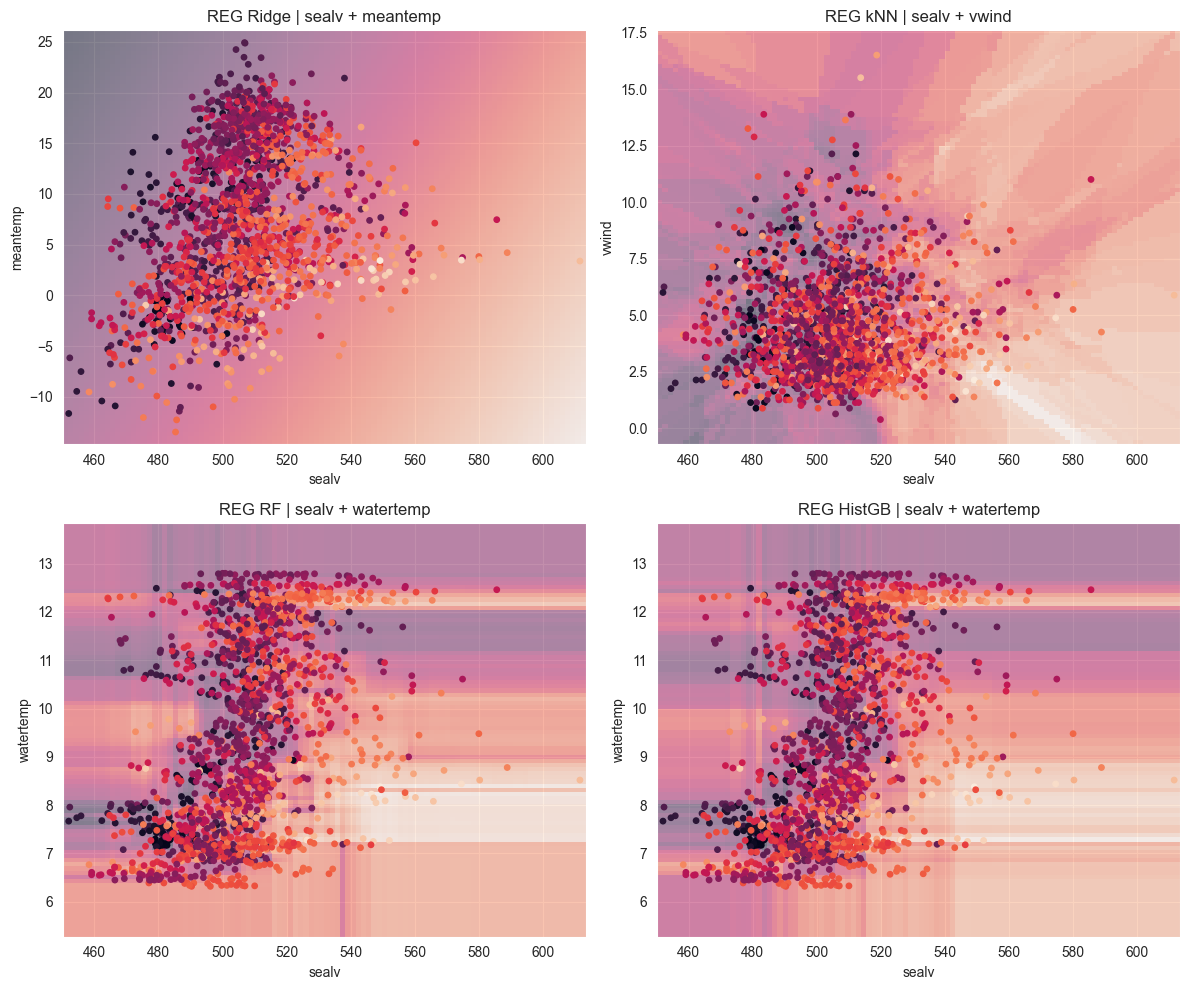

In [26]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.ravel()

draw_boundaries(reg_models["Ridge"], X_train, y_reg_train, "sealv", "meantemp", task="reg", ax=axes[0], title="REG Ridge | sealv + meantemp")
draw_boundaries(reg_models["kNN"], X_train, y_reg_train, "sealv", "vwind", task="reg", ax=axes[1], title="REG kNN | sealv + vwind")
draw_boundaries(reg_models["RandomForest"], X_train, y_reg_train, "sealv", "watertemp", task="reg", ax=axes[2], title="REG RF | sealv + watertemp")
draw_boundaries(reg_models["HistGB"], X_train, y_reg_train, "sealv", "watertemp", task="reg", ax=axes[3], title="REG HistGB | sealv + watertemp")

plt.tight_layout()

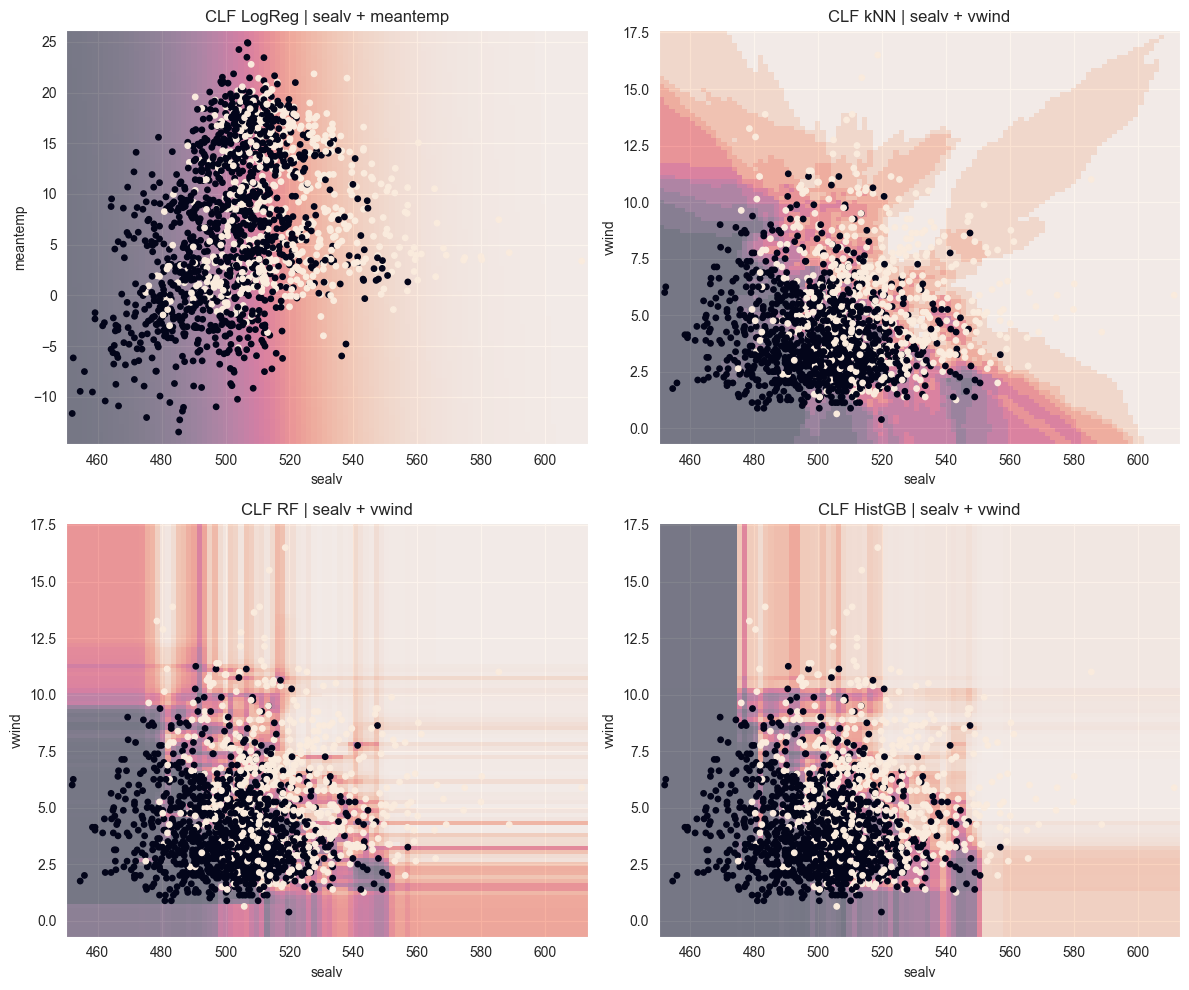

In [27]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.ravel()

draw_boundaries(clf_models["LogReg"], X_train, y_clf_train, "sealv", "meantemp", task="clf", ax=axes[0], title="CLF LogReg | sealv + meantemp")
draw_boundaries(clf_models["kNN"], X_train, y_clf_train, "sealv", "vwind", task="clf", ax=axes[1], title="CLF kNN | sealv + vwind")
draw_boundaries(clf_models["RandomForest"], X_train, y_clf_train, "sealv", "vwind", task="clf", ax=axes[2], title="CLF RF | sealv + vwind")
draw_boundaries(clf_models["HistGB"], X_train, y_clf_train, "sealv", "vwind", task="clf", ax=axes[3], title="CLF HistGB | sealv + vwind")

plt.tight_layout()

# ALE plots

In [28]:
# convert to numpy for alibi lib
feature_names = list(X.columns)

Xn_train = X_train.to_numpy()
Xn_test  = X_test.to_numpy()

yreg_train = y_reg_train.to_numpy()
yclf_train = y_clf_train.to_numpy()